In [ ]:
import numpy as np


delegations = np.array(([
    [1, 0, 0],
    [0, 1, 0],
    [0.3, 0.3, 0.4]
]))

delegations.mean(axis=0) * delegations.shape[0]

array([0.43333333, 0.43333333, 0.13333333])

In [94]:
import numpy as np

def softmax(x, axis=-1, T=1.0):
    e = np.exp((x / T) - np.max(x / T, axis=axis, keepdims=True))
    return e / np.sum(e, axis=axis, keepdims=True)

def simulate(
        class_accuracy: np.ndarray,
        deleg_precision: np.ndarray,
        n_elections = 1_000,
        N: int = 1_000,
        T: float= 1.0
    ):
    

    n_delegators = len(deleg_precision)
    n_predictors = len(class_accuracy)

    class_accuracy = class_accuracy[np.newaxis, :]
    deleg_precision = deleg_precision[:, np.newaxis]
    deleg_imprecision = 1 - deleg_precision 

    accuracies_avg = []
    accuracies_fixed = []
    for _ in range(N):
    
        noisy_accuracy_estimate = np.random.uniform(size=(n_delegators, n_predictors)) 
        accuracy_estimate = deleg_precision * class_accuracy + deleg_imprecision * noisy_accuracy_estimate
        accuracy_estimate = np.maximum(accuracy_estimate, 0.5)
        accuracy_estimate_basline = (accuracy_estimate - 0.5) * 2
        delegations = accuracy_estimate_basline / (np.sum(accuracy_estimate_basline, axis=-1, keepdims=True) + 1e-5)
        delegations = softmax(delegations, T=T)

        M = delegations

        w_avg = M.mean(axis=0)
        w_fixed = np.linalg.matrix_power(M, 100).sum(axis=0) / M.shape[0]


        votes = np.where(np.random.rand(n_elections, n_predictors) < class_accuracy, 1, -1)
        
        tally_avg = votes @ w_avg
        tally_fixed = votes @ w_fixed

        accuracies_avg.append(np.mean(tally_avg > 0))
        accuracies_fixed.append(np.mean(tally_fixed > 0))
        
    # print(f"Mean Accuracy (Avg):   {np.mean(accuracies_avg):.5f}")
    # print(f"Mean Accuracy (Fixed): {np.mean(accuracies_fixed):.5f}")
    
    return np.mean(accuracies_avg) - np.mean(accuracies_fixed)


    

accs = np.array([0.95, 0.5, 0.5, 0.5])
dela = np.array([0.95, 0.05, 0.05, 0.05])

simulate(accs, dela, T=0.01)


np.float64(-0.04503999999999997)

In [97]:
import numpy as np

def softmax(x, axis=-1, T=1.0):
    x_scaled = x / T
    e = np.exp(x_scaled - np.max(x_scaled, axis=axis, keepdims=True))
    return e / np.sum(e, axis=axis, keepdims=True)

def simulate_fast(
        class_accuracy: np.ndarray,
        deleg_precision: np.ndarray,
        n_elections=1_000,
        N: int=1_000,
        T: float=1.0
    ):
    
    n_delegators = len(deleg_precision)
    n_predictors = len(class_accuracy)

    # Reshape for 3D broadcasting: (Batch N, Delegators, Predictors)
    ca = class_accuracy.reshape(1, 1, n_predictors)
    dp = deleg_precision.reshape(1, n_delegators, 1)
    di = 1 - dp

    # 1. Vectorized Matrix (M) Generation
    noise = np.random.uniform(size=(N, n_delegators, n_predictors)) 
    acc_est = np.maximum(dp * ca + di * noise, 0.5)
    
    acc_est_baseline = (acc_est - 0.5) * 2
    delegations = acc_est_baseline / (np.sum(acc_est_baseline, axis=-1, keepdims=True) + 1e-5)
    M = softmax(delegations, axis=-1, T=T) # Shape: (N, n_delegators, n_predictors)

    # 2. Vectorized Weights Calculation
    w_avg = M.mean(axis=1) # Shape: (N, n_predictors)
    # matrix_power automatically handles batches of matrices
    w_fixed = np.linalg.matrix_power(M, 100).sum(axis=1) / n_delegators 

    # 3. Vectorized Votes and Tallies
    votes = np.where(np.random.rand(N, n_elections, n_predictors) < ca, 1, -1)
    
    # Batched matrix multiplication: (N, n_elections, n_predictors) @ (N, n_predictors, 1)
    tally_avg = votes @ np.expand_dims(w_avg, axis=-1)
    tally_fixed = votes @ np.expand_dims(w_fixed, axis=-1)

    return np.mean(tally_avg > 0) - np.mean(tally_fixed > 0)

In [105]:
from scipy.optimize import dual_annealing
import numpy as np

n_elements = 10

def objective(x):
    return simulate_fast(
        x[:n_elements], 
        x[n_elements:], 
        n_elections=200, 
        N=50, 
        T=0.1
    )

bounds = [(0.6, 1.0)] * n_elements + [(0.5, 1.0)] * n_elements
result = dual_annealing(objective, bounds, maxiter=1000)

print(result.x[:n_elements], result.x[n_elements:], result.fun)

[0.67457464 0.99621866 0.62103917 0.63253741 0.63154105 0.60261887
 0.63992577 0.64421244 0.610998   0.66329031] [0.56664398 0.9499115  0.509116   0.53579986 0.62537209 0.52400842
 0.56889479 0.99153367 0.51302048 0.50153413] -0.01550000000000007


In [61]:
np.repeat([[1, 3, 3]], 3, axis=0)

array([[1, 3, 3],
       [1, 3, 3],
       [1, 3, 3]])

In [1]:
import numpy as np

# Initial voting weight vector (v). 
# Index 0: Alice (10,000 votes)
# Index 1: Bob (1 vote)
# Index 2: Charlie (1 vote)
v = np.array([10_000, 1, 1])
total_votes = np.sum(v)

# ---------------------------------------------------------
# Algorithm 2: The Linear System (Fixed Point)
# ---------------------------------------------------------
# Delegation matrix M where M[i, j] = 1 means j delegates to i.
# Alice (0) and Bob (1) delegate to Charlie (2).
M = np.array([
    [0, 0, 0],  # No one delegates to Alice
    [0, 0, 0],  # No one delegates to Bob
    [1, 1, 0]   # Alice and Bob delegate to Charlie
])

# Solve: p = v + M*p  =>  p = (I - M)^(-1) * v
I = np.eye(3)
p_linear = np.linalg.inv(I - M).dot(v)

# ---------------------------------------------------------
# Algorithm 1: Average & Normalize
# ---------------------------------------------------------
# Averaging matrix A. 
# Charlie has 2 incoming links, so averaging treats them as 0.5 each.
A = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.5, 0.5, 0.0]
])

# Solve: p_raw = v + A*p_raw  =>  p_raw = (I - A)^(-1) * v
p_raw = np.linalg.inv(I - A).dot(v)

# Normalize to force the system to maintain the exact total volume of power (10,002)
normalization_factor = total_votes / np.sum(p_raw)
p_averaged = p_raw * normalization_factor

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------
print(f"--- TOTAL VOTES IN SYSTEM: {total_votes} ---\n")

print("ALGORITHM 2: LINEAR SYSTEM (The correct epistemic signal)")
print(f"Alice:   {p_linear[0]:.1f}")
print(f"Bob:     {p_linear[1]:.1f}")
print(f"Charlie: {p_linear[2]:.1f}")
print("Result: Charlie correctly inherits 10,000 from Alice + 1 from Bob + his own 1.\n")

print("ALGORITHM 1: AVERAGE & NORMALIZE (The corrupted signal)")
print(f"Alice:   {p_averaged[0]:.1f}")
print(f"Bob:     {p_averaged[1]:.1f}")
print(f"Charlie: {p_averaged[2]:.1f}")
print("Result: Alice's 10,000 votes were mathematically crushed by Bob's 1 vote.")

--- TOTAL VOTES IN SYSTEM: 10002 ---

ALGORITHM 2: LINEAR SYSTEM (The correct epistemic signal)
Alice:   10000.0
Bob:     1.0
Charlie: 10002.0
Result: Charlie correctly inherits 10,000 from Alice + 1 from Bob + his own 1.

ALGORITHM 1: AVERAGE & NORMALIZE (The corrupted signal)
Alice:   6666.9
Bob:     0.7
Charlie: 3334.4
Result: Alice's 10,000 votes were mathematically crushed by Bob's 1 vote.


In [7]:
import flax
import flax.linen as nn
import jax

class Model(nn.Module):

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.Dense(3)(x)
        return x
    
model = Model()
di = jax.numpy.zeros((1,3))
p = model.init(jax.random.key(123), di)["params"]
type(p["Dense_0"])

dict

In [22]:
import numpy as np

p = np.random.randint(0, 10, size=(10, 3, 5))

i = np.zeros(10).astype(int)

np.take_along_axis(p, i[:, np.newaxis, np.newaxis], axis=-1).shape

(10, 3, 1)

In [46]:
import jax
import jax.numpy as jnp
import optax
from flax import linen as nn
from flax import struct

in_dim = 1
out_dim = 1

class LinearPredictor(nn.Module):

    init_w: float | None = None
    init_b: float | None = None

    def setup(self):
        
        key = self.make_rng("linear")
        k1, k2 = jax.random.split(key)

        bias_value = self.init_b if self.init_b is not None else jax.random.normal(k1, tuple())
        self.bias = self.param(
            "bias", nn.initializers.constant(bias_value), tuple()
        )

        weight_value = self.init_w if self.init_w is not None else jax.random.normal(k2, tuple())
        self.weight = self.param(
            "weight", nn.initializers.constant(weight_value), tuple()
        )
    
    def __call__(self, x):
        return self.weight * x + self.bias
    
LinearPredictor().init(jax.random.key(123), jnp.zeros((1,)))


y = jnp.stack((
    jnp.ones(10),
    jnp.zeros(10),
))

print(y)
print(y.shape)

print(y[jnp.zeros(10, jnp.int32), jnp.arange(10)])


[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(2, 10)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [47]:
import jax
import jax.numpy as jnp
from flax import linen as nn

class LinearPredictor(nn.Module):
    # Set default values directly so the dataclass initializes properly
    init_w: float | None = None
    init_b: float | None = None

    def setup(self):
        # Pass 'params' explicitly to make_rng
        key = self.make_rng('params')
        k1, k2 = jax.random.split(key)

        bias_value = self.init_b if self.init_b is not None else jax.random.normal(k1, tuple())
        self.bias = self.param(
            "bias", nn.initializers.constant(bias_value), tuple()
        )

        weight_value = self.init_w if self.init_w is not None else jax.random.normal(k2, tuple())
        self.weight = self.param(
            "weight", nn.initializers.constant(weight_value), tuple()
        )
    
    def __call__(self, x):
        return self.weight * x + self.bias

def init(k: jax.Array):
    return LinearPredictor().init({"params": k}, jnp.zeros((1,)))["params"]

# Test it
key = jax.random.PRNGKey(0)
print(init(key))

{'bias': Array(1.0235354, dtype=float32), 'weight': Array(1.3438483, dtype=float32)}


In [17]:
import numpy as np

regions = np.array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,  0, 0, 0, 0])
inds = np.where(np.diff(regions) != 0)[0] + 1

inds = np.concatenate((np.array([0]), inds, np.array([regions.size])))
val_region = (inds.size // 2) - 1
mask = np.zeros((regions.size,)).astype(np.int32)
mask[inds[val_region]:inds[val_region + 1]] = 1

print(regions)
print(mask)

[0 0 0 0 1 1 1 1 2 2 2 2 2 2 3 3 3 3 3 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]


=== CIFAR-10 Global Statistics ===
Total samples: 50000
Image shape: (32, 32, 3)
  Class 0: 5000 samples
  Class 1: 5000 samples
  Class 2: 5000 samples
  Class 3: 5000 samples
  Class 4: 5000 samples
  Class 5: 5000 samples
  Class 6: 5000 samples
  Class 7: 5000 samples
  Class 8: 5000 samples
  Class 9: 5000 samples

=== SVHN Global Statistics ===
Total samples: 73257
Image shape: (32, 32, 3)
  Class 0: 4948 samples
  Class 1: 13861 samples
  Class 2: 10585 samples
  Class 3: 8497 samples
  Class 4: 7458 samples
  Class 5: 6882 samples
  Class 6: 5727 samples
  Class 7: 5595 samples
  Class 8: 5045 samples
  Class 9: 4659 samples


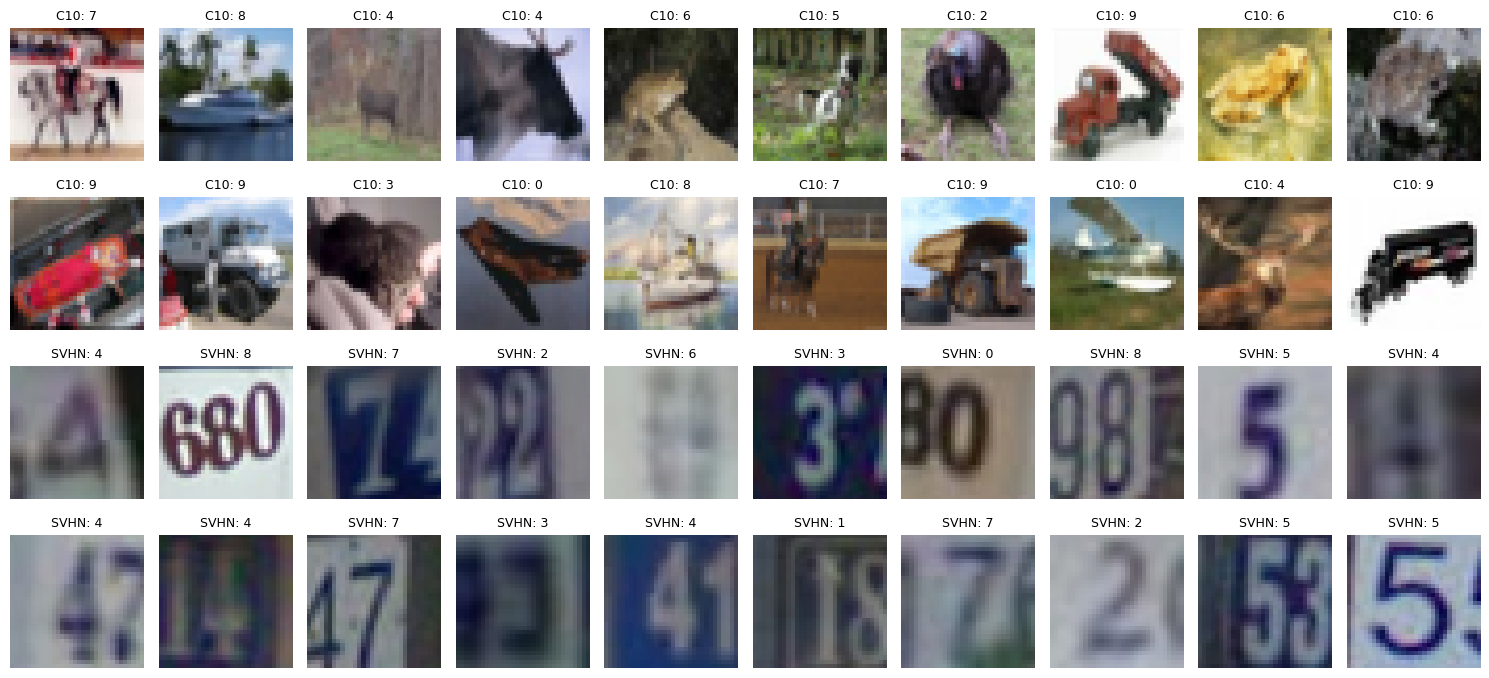

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from cifar10 import Cifar10
from svhn import Svhn

cifar_data = Cifar10.load_cpu(split="train")
svhn_data = Svhn.load_cpu(split="train")

cifar_imgs, cifar_labels = Cifar10.get_xy(cifar_data)
svhn_imgs, svhn_labels = Svhn.get_xy(svhn_data)

cifar_labels = np.array(cifar_labels).flatten()
svhn_labels = np.array(svhn_labels).flatten()

cifar_classes, cifar_counts = np.unique(cifar_labels, return_counts=True)
svhn_classes, svhn_counts = np.unique(svhn_labels, return_counts=True)

print("=== CIFAR-10 Global Statistics ===")
print(f"Total samples: {len(cifar_labels)}")
print(f"Image shape: {cifar_imgs.shape[1:]}")
for cls, count in zip(cifar_classes, cifar_counts):
    print(f"  Class {cls}: {count} samples")

print("\n=== SVHN Global Statistics ===")
print(f"Total samples: {len(svhn_labels)}")
print(f"Image shape: {svhn_imgs.shape[1:]}")
for cls, count in zip(svhn_classes, svhn_counts):
    print(f"  Class {cls}: {count} samples")

fig, axes = plt.subplots(4, 10, figsize=(15, 7))

for i in range(20):
    row = i // 10
    col = i % 10
    ax = axes[row, col]
    ax.imshow(cifar_imgs[i])
    ax.set_title(f"C10: {cifar_labels[i]}", fontsize=9)
    ax.axis("off")

for i in range(20):
    row = (i // 10) + 2
    col = i % 10
    ax = axes[row, col]
    ax.imshow(svhn_imgs[i])
    ax.set_title(f"SVHN: {svhn_labels[i]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path
import pandas as pd

p = Path(".").resolve().parent / "data" / "bikes_hour.csv"

df = pd.read_csv(p)

df = df.sample(len(df))
normalize_features = ("hr", )
noop_features = ("yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed",)
onehot_features = ("season", "mnth", "weekday", "weathersit")
target = "cnt"
cols = normalize_features + noop_features + onehot_features + (target,)
data = {c: df[c].to_numpy() for c in cols}
data

{'hr': array([ 7,  5, 10, ...,  2, 15,  7], shape=(17379,)),
 'yr': array([0, 0, 0, ..., 0, 0, 0], shape=(17379,)),
 'holiday': array([0, 0, 0, ..., 0, 0, 0], shape=(17379,)),
 'workingday': array([1, 1, 1, ..., 1, 1, 0], shape=(17379,)),
 'temp': array([0.6 , 0.22, 0.2 , ..., 0.26, 0.22, 0.66], shape=(17379,)),
 'atemp': array([0.6061, 0.2273, 0.2576, ..., 0.2576, 0.1818, 0.6061],
       shape=(17379,)),
 'hum': array([0.6 , 0.47, 0.4 , ..., 0.93, 0.93, 0.78], shape=(17379,)),
 'windspeed': array([0.2239, 0.1642, 0.    , ..., 0.194 , 0.4627, 0.194 ],
       shape=(17379,)),
 'season': array([3, 1, 1, ..., 2, 1, 3], shape=(17379,)),
 'mnth': array([8, 1, 2, ..., 4, 1, 7], shape=(17379,)),
 'weekday': array([1, 3, 3, ..., 5, 3, 6], shape=(17379,)),
 'weathersit': array([1, 1, 1, ..., 3, 3, 1], shape=(17379,)),
 'cnt': array([284,   3,  51, ...,   7,  43,  71], shape=(17379,))}

In [ ]:
df.loc[:, onehot_features].min()    

season        1
mnth          1
weekday       0
weathersit    1
dtype: int64

In [ ]:
from pathlib import Path
import pandas as pd

p = Path(".").resolve().parent / "data" / "energy" / "data.csv"

df = pd.read_csv(p)
df = df[df["Source"] != "Mixed"]

df = df.sample(len(df))


categorize_features = ("Source", "Day_Name", "Day_Name", "Month_Name", "Season")

normalize_features = ("Start_Hour", "End_Hour", "Day_of_Year")
noop_features = ()
onehot_features = categorize_features
target = ("Production",)
df

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
42581,1/21/2021,18,19,Wind,21,Thursday,January,Winter,13557
45951,9/3/2020,15,16,Solar,247,Thursday,September,Fall,6444
45071,10/10/2020,8,9,Wind,284,Saturday,October,Fall,2390
8920,11/24/2024,18,19,Wind,329,Sunday,November,Fall,19758
26719,11/13/2022,19,20,Wind,317,Sunday,November,Fall,1926
...,...,...,...,...,...,...,...,...,...
8131,12/27/2024,1,2,Wind,362,Friday,December,Winter,2317
43693,12/6/2020,9,10,Wind,341,Sunday,December,Winter,2714
36609,9/27/2021,15,16,Wind,270,Monday,September,Fall,10358
27757,10/1/2022,0,1,Wind,274,Saturday,October,Fall,13056


In [42]:
type(())

tuple

In [45]:
df["Season"].value_counts()

Season
Summer    13247
Spring    13241
Fall      13110
Winter    12264
Name: count, dtype: int64